In [50]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
# Modelling
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score
from sklearn.model_selection import train_test_split


from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder


In [51]:
df=pd.read_csv('processed_data/integrated_cutomer_dataset.csv')

In [52]:
df.head()

,tenure_months,contract_type,monthly_spend,days_since_last_order,support_tickets_30d,total_spend,order_count,avg_order_value,payment_method,autopay,...,billing_cycle,autopay_enabled,paperless_billing,late_payments_12m,price_increase_last_year,discount_pct,payment_failures_90d,billing_address_city,tax_exempt,invoice_delivery
0,65,annual,132.82,223,9,9670.8,12,322.36,credit_card,0,...,No Plan,0.0,0.0,0.0,0.0,0.0,0.0,No Plan,0.0,No Plan
1,53,annual,286.50,6,0,22844.1,76,761.47,ach,1,...,annual,1.0,1.0,2.0,0.0,14.7,0.0,North Hollyfurt,0.0,mail
2,46,biennial,65.39,2,0,3891.6,41,129.72,invoice,0,...,No Plan,0.0,0.0,0.0,0.0,0.0,0.0,No Plan,0.0,No Plan
3,87,annual,55.78,322,4,3067.8,14,102.26,invoice,1,...,monthly,1.0,1.0,0.0,1.0,5.1,0.0,South Allisonview,0.0,mail
4,2,annual,269.11,27,4,21353.4,78,711.78,credit_card,0,...,monthly,1.0,0.0,1.0,0.0,21.1,0.0,Lake Craigburgh,0.0,mail


In [53]:
df.columns

Index(['tenure_months', 'contract_type', 'monthly_spend',
       'days_since_last_order', 'support_tickets_30d', 'total_spend',
       'order_count', 'avg_order_value', 'payment_method', 'autopay',
       'num_products_owned', 'complaint_count', 'nps_score',
       'satisfaction_score', 'churned', 'churn_reason', 'predicted_churn_prob',
       'retention_offer_sent', 'offer_accepted', 'country', 'state', 'city',
       'age', 'gender', 'occupation', 'marital_status', 'household_size',
       'segment', 'lifetime_value', 'loyalty_points', 'preferred_channel',
       'preferred_language', 'account_status', 'referral_source',
       'email_opt_in', 'sms_opt_in', 'login_frequency_30d',
       'pages_per_session', 'avg_session_duration_min', 'mobile_app_usage_pct',
       'email_open_rate', 'email_click_rate', 'push_notification_opt_in',
       'csat_score', 'feature_adoption_score', 'community_forum_posts',
       'referrals_made', 'support_escalations_90d', 'product_tours_completed',
    

In [54]:
df.shape

(150000, 73)

In [55]:
df.drop(columns=[
    "churn_reason",              # Data leakage
    "predicted_churn_prob",      # Data leakage
    "plan_name",                 # ~20,000 unique values
    "billing_address_city",      # ~13,000 unique values
    "city",                      # ~13,000 unique values
    "occupation",                # 640 unique values
    "country",                   # 195 categories
    "state"                      # 60 categories
], inplace=True)

In [56]:
df.shape

(150000, 65)

In [57]:
X=df.drop("churned",axis=1)
y = df["churned"]

In [58]:
X.shape

(150000, 64)

In [59]:
num_cols=X.select_dtypes(include=['int64','Float64']).columns
cat_cols=X.select_dtypes(exclude=['int64','Float64']).columns

In [60]:
for col in cat_cols:
    print(col)
    print(X[col].nunique())
    print(X[col].unique())
    print("===============")
    

contract_type
3
<StringArray>
['annual', 'biennial', 'month-to-month']
Length: 3, dtype: str
payment_method
4
<StringArray>
['credit_card', 'ach', 'invoice', 'paypal']
Length: 4, dtype: str
retention_offer_sent
4
<StringArray>
['email', 'sms', 'call', 'none']
Length: 4, dtype: str
gender
4
<StringArray>
['Unknown', 'Other', 'M', 'F']
Length: 4, dtype: str
marital_status
5
<StringArray>
['Unknown', 'widowed', 'married', 'divorced', 'single']
Length: 5, dtype: str
segment
5
<StringArray>
['Unknown', 'Gold', 'Platinum', 'Silver', 'Bronze']
Length: 5, dtype: str
preferred_channel
5
<StringArray>
['Unknown', 'web', 'email', 'sms', 'app']
Length: 5, dtype: str
preferred_language
5
<StringArray>
['Unknown', 'de', 'es', 'fr', 'en']
Length: 5, dtype: str
account_status
4
<StringArray>
['Unknown', 'suspended', 'active', 'inactive']
Length: 4, dtype: str
referral_source
6
<StringArray>
['Unknown', 'paid_ads', 'partner', 'event', 'organic', 'referral']
Length: 6, dtype: str
engagement_tier
4
<Stri

In [61]:
preprocessor=ColumnTransformer(
    transformers=[
        ("Encoding",OneHotEncoder(handle_unknown="ignore"),cat_cols),
        ("Scaling",StandardScaler(),num_cols)
    ]
)

In [62]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
X_train=preprocessor.fit_transform(X_train)
X_test=preprocessor.transform(X_test)

In [63]:
X_train.shape, X_test.shape

((120000, 113), (30000, 113))

In [64]:
def evaluate_metrics(true,pred):
    accuracy=accuracy_score(true,pred)
    precision=precision_score(true,pred)
    recall=recall_score(true,pred)
    f1=f1_score(true,pred)
    roc=roc_auc_score(true,pred)
    return (accuracy,precision,recall,f1,roc)


In [65]:
models={
    'logistic Regression':LogisticRegression(),
    'Random Forest':RandomForestClassifier(),
    'XG Boost':XGBClassifier(),
    'Light GBM':LGBMClassifier()
}
results = []

for name, model in models.items():

    print("=" * 50)
    print(f"Model: {name}")

    print("Training...")
    model.fit(X_train, y_train)
    print("Training Completed.")

    print("Testing...")
    y_pred = model.predict(X_test)
    print("Testing Completed.")

    acc, pre, rec, f1, roc = evaluate_metrics(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": pre,
        "Recall": rec,
        "F1-Score": f1,
        "ROC-AUC": roc
    })

    print("\nModel Performance")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {pre:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc:.4f}")



Model: logistic Regression
Training...
Training Completed.
Testing...
Testing Completed.

Model Performance
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-Score : 1.0000
ROC-AUC  : 1.0000
Model: Random Forest
Training...
Training Completed.
Testing...
Testing Completed.

Model Performance
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-Score : 1.0000
ROC-AUC  : 1.0000
Model: XG Boost
Training...
Training Completed.
Testing...
Testing Completed.

Model Performance
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-Score : 1.0000
ROC-AUC  : 1.0000
Model: Light GBM
Training...
[LightGBM] [Info] Number of positive: 51789, number of negative: 68211
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.051610 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4925
[LightGBM] [Info] Number of data points in the train set: 120000, number of used features: 113
[LightGBM] [Info] [binary:BoostF

In [66]:
print(X.columns.tolist())

['tenure_months', 'contract_type', 'monthly_spend', 'days_since_last_order', 'support_tickets_30d', 'total_spend', 'order_count', 'avg_order_value', 'payment_method', 'autopay', 'num_products_owned', 'complaint_count', 'nps_score', 'satisfaction_score', 'retention_offer_sent', 'offer_accepted', 'age', 'gender', 'marital_status', 'household_size', 'segment', 'lifetime_value', 'loyalty_points', 'preferred_channel', 'preferred_language', 'account_status', 'referral_source', 'email_opt_in', 'sms_opt_in', 'login_frequency_30d', 'pages_per_session', 'avg_session_duration_min', 'mobile_app_usage_pct', 'email_open_rate', 'email_click_rate', 'push_notification_opt_in', 'csat_score', 'feature_adoption_score', 'community_forum_posts', 'referrals_made', 'support_escalations_90d', 'product_tours_completed', 'wishlist_items', 'cart_abandonment_rate', 'promo_code_usage_90d', 'engagement_tier', 'recency_days', 'frequency', 'monetary', 'r_score', 'f_score', 'm_score', 'rfm_segment', 'monthly_recurring_

In [67]:
corr = df.corr(numeric_only=True)["churned"].sort_values(ascending=False)
print(corr)

churned                      1.000000
days_since_last_order        0.907883
support_tickets_30d          0.828525
complaint_count              0.566990
total_spend                  0.294498
avg_order_value              0.294498
monthly_spend                0.294498
pages_per_session            0.004198
price_increase_last_year     0.003614
email_click_rate             0.003097
login_frequency_30d          0.003082
discount_pct                 0.002770
autopay_enabled              0.002637
payment_failures_90d         0.002421
recency_days                 0.001987
monetary                     0.001909
loyalty_points               0.001760
age                          0.001688
sms_opt_in                   0.001634
feature_adoption_score       0.001507
m_score                      0.001343
offer_accepted               0.001156
csat_score                   0.001134
frequency                    0.000982
num_products_owned           0.000841
avg_session_duration_min     0.000469
tax_exempt  

In [68]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

churned
0    0.568425
1    0.431575
Name: proportion, dtype: float64
churned
0    0.568433
1    0.431567
Name: proportion, dtype: float64


In [69]:
from sklearn.metrics import confusion_matrix

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))

[[17053     0]
 [    0 12947]]


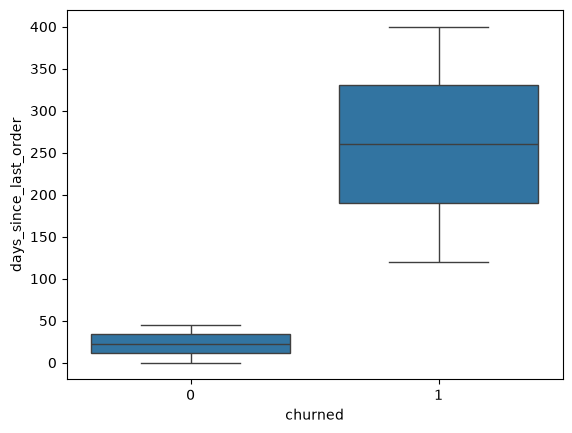

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df["churned"], y=df['days_since_last_order'])
plt.show()

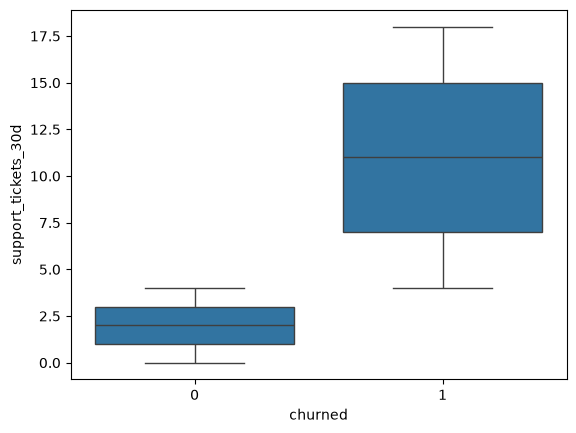

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df["churned"], y=df['support_tickets_30d'])
plt.show()

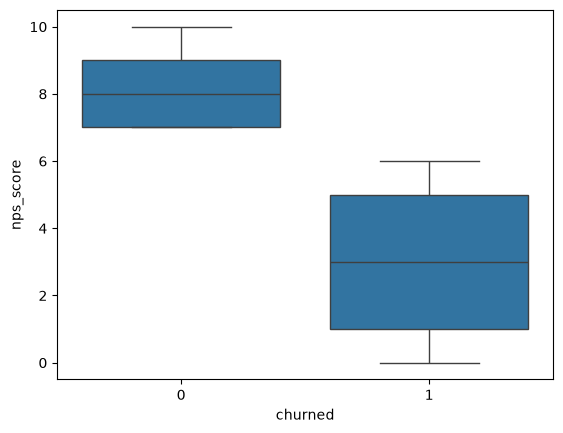

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df["churned"], y=df['nps_score'])
plt.show()

## Dataset Limitation

This project uses a synthetic customer churn dataset. During exploratory data analysis, key features such as `days_since_last_order`, `support_tickets_30d`, and `nps_score` exhibited very strong separation between churned and non-churned customers. Consequently, all evaluated machine learning models achieved near-perfect performance.

This behavior is attributed to the characteristics of the synthetic dataset rather than the inherent superiority of the models. In a real-world production environment, customer behavior is more complex, feature distributions typically overlap, and model performance is expected to be lower. Therefore, the results should be interpreted as a demonstration of the end-to-end machine learning pipeline rather than an estimate of real-world predictive performance.